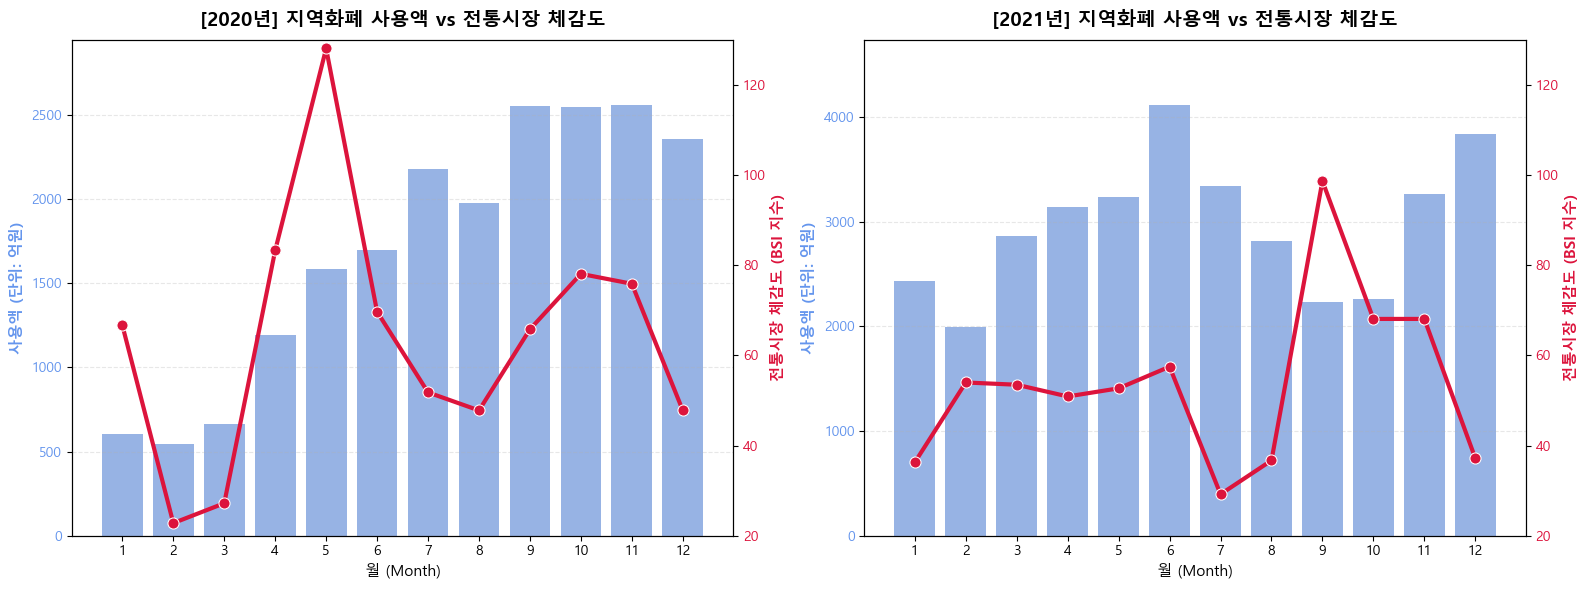

In [1]:
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
import warnings

warnings.filterwarnings('ignore') # 경고창 숨기기

# ==========================================
# 1. 폰트 및 로드 함수 설정
# ==========================================
plt.rcParams['font.family'] = 'Malgun Gothic' # Mac 사용자는 'AppleGothic'
plt.rcParams['axes.unicode_minus'] = False

def load_csv(file_path):
    encodings = ['utf-8-sig', 'cp949', 'utf-8', 'euc-kr']
    for enc in encodings:
        try:
            return pd.read_csv(file_path, encoding=enc)
        except UnicodeDecodeError:
            continue
    raise ValueError(f"{file_path} 파일을 읽을 수 없습니다.")

# 데이터 불러오기 ('전통시장' BSI 데이터)
df_bsi = load_csv('전통시장_지역별_실적_및_전망_20260323130845.csv')
df_1922 = load_csv('지역화폐발행및이용현황(2019~2022)_수정.csv')
df_23 = load_csv('지역화폐발행및이용현황(2023).csv')
df_2425 = load_csv('지역화폐발행및이용현황 (2).csv')


# ==========================================
# 2. 데이터 전처리 (전통시장 BSI & 지역화폐)
# ==========================================
# [전통시장 BSI 전처리] '경기' 지역 추출
row_gg = df_bsi[df_bsi['지역별(1)'] == '경기']
type_row = df_bsi.iloc[0]
chegam_cols = type_row[type_row == '체감'].index

bsi_gg = row_gg[chegam_cols].copy().T.reset_index()
bsi_gg.columns = ['원본연월', 'BSI']
bsi_gg['Year'] = bsi_gg['원본연월'].str.split('.').str[0].astype(int)
bsi_gg['Month'] = bsi_gg['원본연월'].str.split('.').str[1].astype(int)
bsi_gg['BSI'] = pd.to_numeric(bsi_gg['BSI'], errors='coerce')

# [지역화폐 전처리] 단위 '억원' 통일 및 병합
df_1922['사용액_억원'] = pd.to_numeric(df_1922['월별사용액(천원)'], errors='coerce') / 100000
df_23['사용액_억원'] = pd.to_numeric(df_23['월별사용액(백만원)'], errors='coerce') / 100
df_2425['사용액_억원'] = pd.to_numeric(df_2425['월별사용액(백만원)'], errors='coerce') / 100

curr_all = pd.concat([
    df_1922[['기준년월', '사용액_억원']],
    df_23[['기준년월', '사용액_억원']],
    df_2425[['기준년월', '사용액_억원']]
]).dropna(subset=['기준년월'])

curr_all['Year'] = curr_all['기준년월'].str.split('-').str[0].astype(int)
curr_all['Month'] = curr_all['기준년월'].str.split('-').str[1].astype(int)
curr_grouped = curr_all.groupby(['Year', 'Month'])['사용액_억원'].sum().reset_index()

# 데이터 병합
merged_df = pd.merge(curr_grouped, bsi_gg[['Year', 'Month', 'BSI']], on=['Year', 'Month'], how='inner')


# ==========================================
# 3. 데이터 시각화 (2020년, 2021년 / Y축 0부터 시작)
# ==========================================
years_early = [2020, 2021]
data_early = merged_df[merged_df['Year'].isin(years_early)]

# 1행 2열 격자 생성 (나란히 배치)
fig, axes = plt.subplots(nrows=1, ncols=2, figsize=(16, 6))

for i, year in enumerate(years_early):
    ax1 = axes[i]
    data_year = data_early[data_early['Year'] == year].sort_values('Month')
    
    # [Y축 1] 막대 그래프: 경기도 지역화폐 사용액
    sns.barplot(
        data=data_year, 
        x='Month', 
        y='사용액_억원', 
        color='cornflowerblue', 
        alpha=0.75, 
        ax=ax1
    )
    ax1.set_title(f'[{year}년] 지역화폐 사용액 vs 전통시장 체감도', fontsize=14, fontweight='bold', pad=10)
    ax1.set_xlabel('월 (Month)', fontsize=11)
    ax1.set_ylabel('사용액 (단위: 억원)', fontsize=11, fontweight='bold', color='cornflowerblue')
    ax1.tick_params(axis='y', labelcolor='cornflowerblue')
    
    # ★ 핵심: Y축(사용액)을 '0'부터 시작하도록 명시적으로 고정 ★
    # 데이터의 최대값보다 15% 여유를 두어 깔끔하게 보이도록 설정
    y1_max = data_year['사용액_억원'].max() * 1.15
    ax1.set_ylim(0, y1_max) 
    
    # [Y축 2] 선 그래프: 경기도 '전통시장' 체감도 BSI
    ax2 = ax1.twinx()
    sns.lineplot(
        x=range(len(data_year)), 
        y=data_year['BSI'], 
        marker='o', 
        markersize=8,
        linewidth=3,
        color='crimson', 
        ax=ax2
    )
    ax2.set_ylabel('전통시장 체감도 (BSI 지수)', fontsize=11, fontweight='bold', color='crimson')
    ax2.tick_params(axis='y', labelcolor='crimson')
    
    # BSI 지수축(y2) 고정 (20 ~ 110)
    ax2.set_ylim(20, 130) 
    ax1.grid(axis='y', linestyle='--', alpha=0.3)

plt.tight_layout()
plt.show()

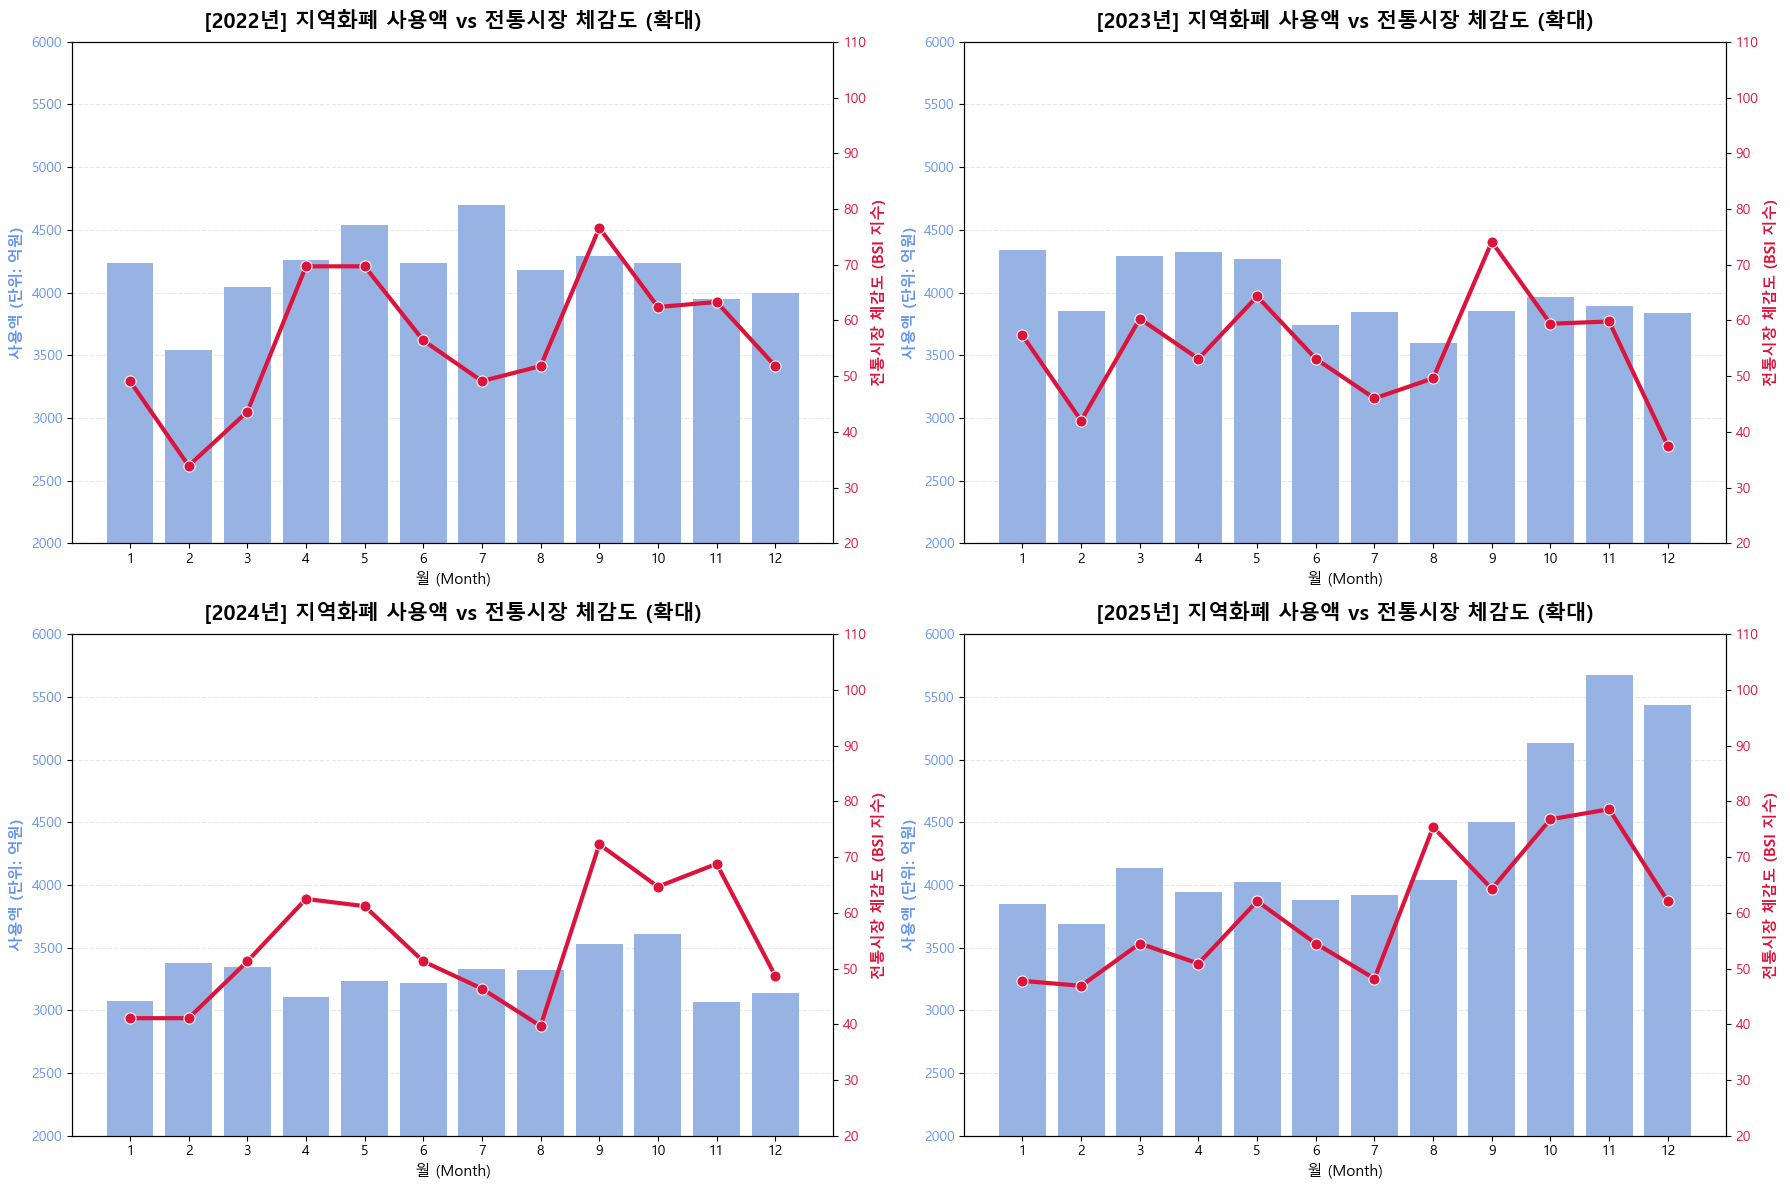

In [2]:
# 3. 데이터 시각화 (2022~2025년 / Y축 확대)
# ==========================================
years_later = [2022, 2023, 2024, 2025]
data_later = merged_df[merged_df['Year'].isin(years_later)]

# 2x2 격자 생성
fig, axes = plt.subplots(nrows=2, ncols=2, figsize=(18, 12))
axes = axes.flatten()

for i, year in enumerate(years_later):
    ax1 = axes[i]
    data_year = data_later[data_later['Year'] == year].sort_values('Month')
    
    # [Y축 1] 막대 그래프: 경기도 지역화폐 사용액
    sns.barplot(
        data=data_year, 
        x='Month', 
        y='사용액_억원', 
        color='cornflowerblue', 
        alpha=0.75, 
        ax=ax1
    )
    ax1.set_title(f'[{year}년] 지역화폐 사용액 vs 전통시장 체감도 (확대)', fontsize=15, fontweight='bold', pad=10)
    ax1.set_xlabel('월 (Month)', fontsize=11)
    ax1.set_ylabel('사용액 (단위: 억원)', fontsize=11, fontweight='bold', color='cornflowerblue')
    ax1.tick_params(axis='y', labelcolor='cornflowerblue')
    
    # ★ Y축(사용액) 범위를 2000 ~ 6000으로 제한 ★
    ax1.set_ylim(2000, 6000) 
    
    # [Y축 2] 선 그래프: 경기도 '전통시장' 체감도 BSI
    ax2 = ax1.twinx()
    sns.lineplot(
        x=range(len(data_year)), 
        y=data_year['BSI'], 
        marker='o', 
        markersize=8,
        linewidth=3,
        color='crimson', 
        ax=ax2
    )
    ax2.set_ylabel('전통시장 체감도 (BSI 지수)', fontsize=11, fontweight='bold', color='crimson')
    ax2.tick_params(axis='y', labelcolor='crimson')
    
    # BSI 지수축(y2) 고정 (20 ~ 110)
    ax2.set_ylim(20, 110) 
    ax1.grid(axis='y', linestyle='--', alpha=0.3)

plt.tight_layout()
plt.show()